# Notebook to use SEAS5 forecasts and adjust for bias against ERA5

In [ ]:
#Install FORECAST.SEAS5.requirements.txt

# Full Pipeline

python pipeline.py

# Targeted use

In [39]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
import FORECAST.SEAS5.pipeline as pipeline

# # Build ERA5 climatology once (reused forever afterwards)
# pipeline.step1_download_era5()
# pipeline.step2_build_climatology()

# # Download + correct only the April 2026 initialization
# pipeline.step3_download_seas5(
#     years=[2025],
#     init_months=[4],
#     leadtime_months=[1, 2, 3, 4, 5, 6],
# )
pipeline.step4_apply_correction(years=[2025])


2026-04-21 18:28:04,547 | INFO    | pipeline | === Step 4: Apply delta correction ===
2026-04-21 18:28:04,548 | INFO    | FORECAST.SEAS5.bias_correction | Correcting: era5_clim_sst_1993-2016.nc + seas5anom_sst_2025-2025.nc
2026-04-21 18:28:04,596 | INFO    | FORECAST.SEAS5.regrid | Regridding: source 481x1440 -> target 120x360 (method=linear)
2026-04-21 18:28:05,674 | INFO    | FORECAST.SEAS5.bias_correction | Saved corrected field: data/seas5_corrected/seas5corrected_sst_2025-2025.nc
2026-04-21 18:28:05,678 | INFO    | FORECAST.SEAS5.bias_correction | Correcting: era5_clim_msl_1993-2016.nc + seas5anom_msl_2025-2025.nc
2026-04-21 18:28:05,736 | INFO    | FORECAST.SEAS5.regrid | Regridding: source 481x1440 -> target 120x360 (method=linear)
2026-04-21 18:28:06,334 | INFO    | FORECAST.SEAS5.bias_correction | Saved corrected field: data/seas5_corrected/seas5corrected_msl_2025-2025.nc
2026-04-21 18:28:06,337 | INFO    | FORECAST.SEAS5.bias_correction | Correcting: era5_clim_t_pl_1993-2016.

# Backtest 2017-2025

In [ ]:
pipeline.step3_download_seas5(
    years=list(range(2017, 2026)),
    init_months=[4, 5, 6,],
)
pipeline.step4_apply_correction(years=list(range(2017, 2026)))

# Visualization tests

In [12]:
import xarray as xr
import matplotlib.pyplot as plt 

mslp_corr = xr.open_dataset("data/seas5_corrected/seas5corrected_msl_2025-2025.nc").msl.isel(
    forecastMonth=0, forecast_reference_time=0
).mean(["number"])
mslp_anom = xr.open_dataset(
    "data/seas5_anomaly/seas5anom_msl_2025-2025.nc"
).msla.isel(forecastMonth=0, forecast_reference_time=0, number=0)
mslp_seas5 = xr.open_dataset("/home/mbaldacchino/data/shit/SEAS5_hist.nc").msl.sel(
    forecastMonth=1, forecast_reference_time="2025-04-01"
).mean(["number"])
mslp_seas5 = (
    mslp_seas5.assign_coords(longitude=(((mslp_seas5.longitude + 180) % 360) - 180))
    .sortby("longitude").sel(latitude=slice(60,-60))
)
mslp = (
    xr.open_dataset("/home/mbaldacchino/data/shit/data_stream-moda_stepType-avgua.nc")
    )
mslp = (
    mslp.assign_coords(longitude=(((mslp.longitude + 180) % 360) - 180))
    .sortby("longitude")
    .msl.sel(valid_time="2025-04-01", latitude=slice(60,-60))
)

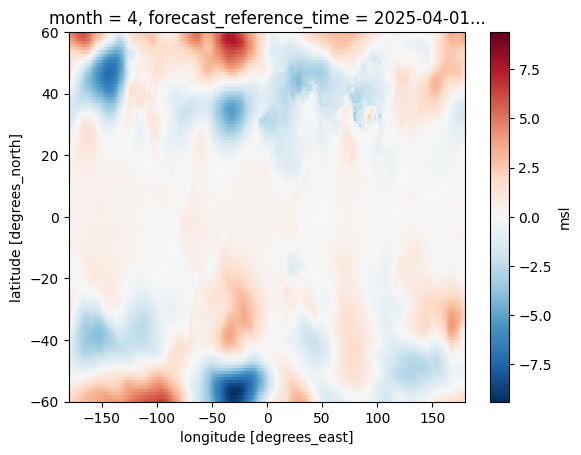

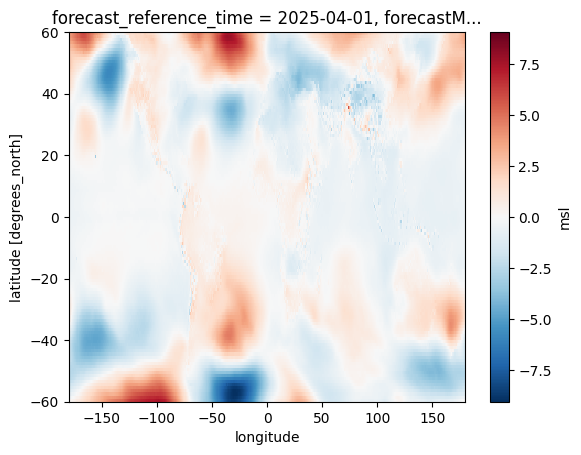

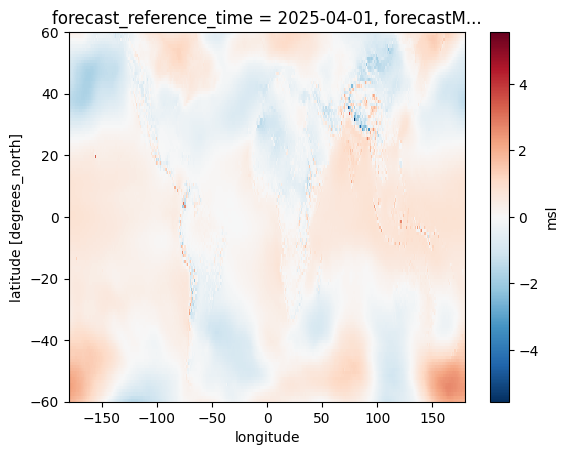

In [16]:
((mslp_corr - mslp)/100).plot.pcolormesh()
plt.show()
((mslp_seas5 - mslp) / 100).plot.pcolormesh()
plt.show()
(-(mslp_seas5 - mslp_corr) / 100).plot.pcolormesh()
plt.show()


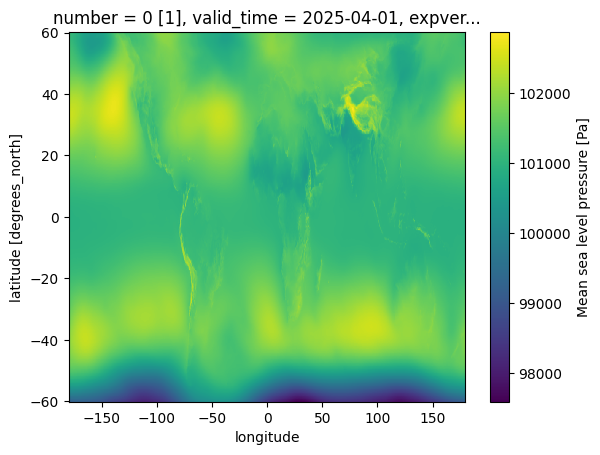

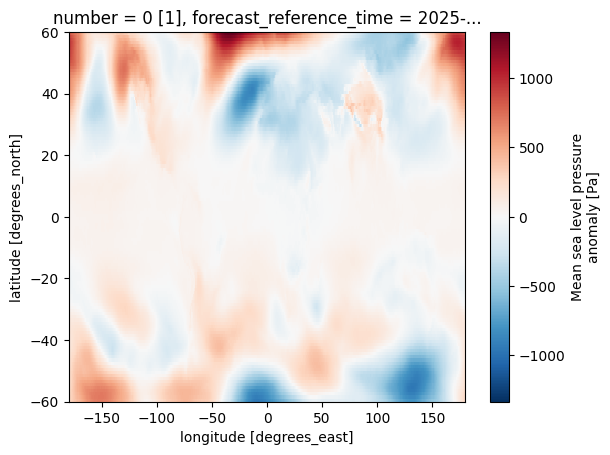

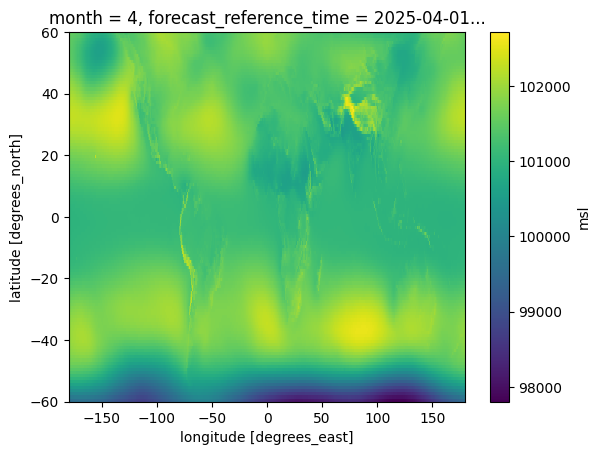

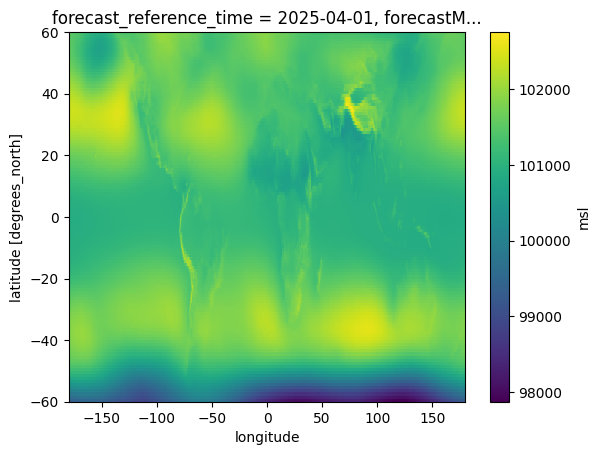

In [14]:
mslp.plot.pcolormesh()
plt.show()
mslp_anom.plot.pcolormesh()
plt.show()
mslp_corr.plot.pcolormesh()
plt.show()
mslp_seas5.plot.pcolormesh()
plt.show()